# Training Faster R-CNN

This notebook evaluates Faster R-CNN as a two-stage object detector for the TACO trash dataset. Unlike Mask R-CNN, this model predicts only bounding boxes and class labels, so the experiment focuses on detection quality rather than instance segmentation.

The notebook starts with a simple filtered top-10 category baseline and then repeats training with the merged taxonomy that improved the Mask R-CNN v1 experiments. Both heads-only training and full-model fine-tuning are tested, and the resulting runs are compared using bbox mAP, mAP@50, recall, match rate, and class accuracy on matched detections.

The goal is not only to train another model, but to check whether the same data-treatment improvements that helped Mask R-CNN also transfer to Faster R-CNN, and whether this architecture is competitive enough to be used for inference.


## Install Packages

This notebook is designed to run both locally and in Google Colab. The first cell installs the packages that are required for Faster R-CNN training and evaluation: detection metrics, COCO utilities, TensorBoard logging, dataset download helpers, and augmentation support. If the environment already has these dependencies, this cell can be skipped.


In [1]:
!pip install torchmetrics pycocotools gdown tqdm tensorboard albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 17.0 MB/s eta 0:00:00a 0:00:01


## Import Packages

This section imports the libraries used across the notebook. The key components are PyTorch and TorchVision for model training, TorchMetrics for mAP evaluation, pandas for annotation processing, and matplotlib for result visualization.


In [2]:
import os
import pandas as pd
import json
from tqdm import tqdm

import ast
from PIL import Image, ImageDraw
import os
import torch
import math

import numpy as np
from torchvision.io import read_image
from torchvision import tv_tensors
from torchvision.transforms.v2 import functional as F
from torch.utils.data import Dataset, Subset, DataLoader, random_split, WeightedRandomSampler
from torch import nn
import random
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torch.utils.tensorboard import SummaryWriter
from matplotlib import colors, pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2

from torchvision.ops import box_iou

from torchmetrics.detection import (
    MeanAveragePrecision,
    IntersectionOverUnion,
    GeneralizedIntersectionOverUnion,
    DistanceIntersectionOverUnion,
    CompleteIntersectionOverUnion,
)
from torchmetrics.segmentation import DiceScore, GeneralizedDiceScore, MeanIoU

%matplotlib inline

## Set Environments Path

The notebook uses different root paths depending on whether it is running in Colab or on a remote/local machine. This section defines paths for the TACO dataset, intermediate dataframe files, checkpoints, TensorBoard logs, and exported run artifacts.


In [3]:
def is_google_colab() -> bool:
    """Check whether the notebook is running in Google Colab.
    
    Returns:
        bool: ``True`` in a Colab runtime; otherwise ``False``.
    """
    try:
        import google.colab
        return True
    except ImportError:
        return False


IN_COLAB = is_google_colab()

if IN_COLAB:
    ROOT_PATH = "/content"
    DATAFRAME_PATH = "/content/drive/MyDrive/taco_trash"
    DEFAULT_RUNS_PATH = "/content/drive/MyDrive/taco_trash"
else:
    ROOT_PATH = "/home/ubuntu"
    DATAFRAME_PATH = os.path.join(ROOT_PATH, "taco_trash")
    DEFAULT_RUNS_PATH = os.path.join(ROOT_PATH, "taco_trash")

TACO_CLASSIFICATION_PATH = os.path.join(ROOT_PATH, "taco")

In [4]:
if is_google_colab():
    from google.colab import drive
    drive.mount("/content/drive")
else:
    !curl https://rclone.org/install.sh | sudo bash

Mounted at /content/drive


In [5]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [6]:
torch.cuda.current_device()
torch.cuda.get_device_name(0)
device = torch.device("cuda")
device

device(type='cuda')

In [7]:
!gdown 1CUxA2TcZFhVJWvNH4qwlOSGDPlxodRPF
!unzip taco.zip -d $ROOT_PATH

Downloading...
From (original): https://drive.google.com/uc?id=1CUxA2TcZFhVJWvNH4qwlOSGDPlxodRPF
From (redirected): https://drive.google.com/uc?id=1CUxA2TcZFhVJWvNH4qwlOSGDPlxodRPF&confirm=t&uuid=1f24d002-078e-4811-885c-5f7815612bcf
To: /content/taco.zip
100% 5.23G/5.23G [00:40<00:00, 128MB/s] 
Archive:  taco.zip
   creating: /content/content/drive/MyDrive/taco_dataset/taco/
  inflating: /content/content/drive/MyDrive/taco_dataset/taco/annotations.json  
   creating: /content/content/drive/MyDrive/taco_dataset/taco/batch_14/
  inflating: /content/content/drive/MyDrive/taco_dataset/taco/batch_14/000011.jpg  
  inflating: /content/content/drive/MyDrive/taco_dataset/taco/batch_14/000007.jpg  
  inflating: /content/content/drive/MyDrive/taco_dataset/taco/batch_14/000004.jpg  
  inflating: /content/content/drive/MyDrive/taco_dataset/taco/batch_14/000000.jpg  
  inflating: /content/content/drive/MyDrive/taco_dataset/taco/batch_14/000014.jpg  
  inflating: /content/content/drive/MyDrive/taco_

In [8]:
!gdown 1lj6H8pIbHjgrgNRWHoc41Nr8bi0FZ7mt # annotations_processed.csv

Downloading...
From: https://drive.google.com/uc?id=1lj6H8pIbHjgrgNRWHoc41Nr8bi0FZ7mt
To: /content/annotations_processed.csv
100% 3.10M/3.10M [00:00<00:00, 129MB/s]


In [9]:
def parse_bbox(v):
    if isinstance(v, str):
        return ast.literal_eval(v)
    return v
    
if is_google_colab():
    df = pd.read_csv(os.path.join(ROOT_PATH, "annotations_processed.csv"))
else:
    ann_path = os.path.join(TACO_CLASSIFICATION_PATH, "annotations.json")
    with open(ann_path, "r") as f:
        data = json.load(f)

    print(data.keys())

    for key in data.keys():
        if isinstance(data[key], list):
            print(key, len(data[key]))

    df_images = pd.DataFrame(data["images"])
    df_annotations = pd.DataFrame(data["annotations"])
    df_categories = pd.DataFrame(data["categories"])
    df_scene_annotations = pd.DataFrame(data["scene_annotations"])
    df_scene_categories = pd.DataFrame(data["scene_categories"])

    df = df_annotations.merge(
        df_images,
        left_on="image_id",
        right_on="id",
        how="left",
        suffixes=("", "_img"),
    ).merge(
        df_categories,
        left_on="category_id",
        right_on="id",
        how="left",
        suffixes=("", "_cat"),
    ).rename(
        columns={
            "id_x": "annotation_id",
            "id_y": "category_id_full",
            "name": "category_name",
        }
    )
    df['file_path'] = df['file_name'].map(lambda x: os.path.join(TACO_CLASSIFICATION_PATH, x) )

## Setup common functions

This section contains reusable dataset, model, training, evaluation, checkpointing, and plotting utilities. Faster R-CNN is a detection-only model, so the training and evaluation helpers use bounding boxes and class labels only. Masks may still exist in the original dataset, but they are ignored for this model.


In [10]:
def polygons_to_masks(segmentation, height, width):
    """Rasterize polygon segmentations into binary masks.
    
    Args:
        segmentation (list[list[float]]): Polygon coordinate lists for one instance.
        height (int): Output mask height in pixels.
        width (int): Output mask width in pixels.
    
    Returns:
        torch.Tensor: Stacked masks with shape ``[N, H, W]``.
    """
    masks = []

    for seg in segmentation:
        # Create empty mask
        mask = Image.new("L", (width, height), 0)
        draw = ImageDraw.Draw(mask)

        # Create corrdinates tuples
        polygon = [(seg[i], seg[i+1]) for i in range(0, len(seg), 2)]

        # Fill this mask in empty mask image
        draw.polygon(polygon, outline=1, fill=1)

        #  PIL => numpy => torch
        mask = torch.from_numpy(np.array(mask, dtype=np.uint8))

        masks.append(mask)

    # Combine
    if len(masks) > 0:
        masks = torch.stack(masks)  # [N, H, W]
    else:
        masks = torch.zeros((0, height, width), dtype=torch.uint8)

    return masks

def boxes_from_masks(masks):
    """Compute tight ``xyxy`` bounding boxes from binary masks.
    
    Args:
        masks (torch.Tensor): Binary instance masks with shape ``[N, H, W]``.
    
    Returns:
        torch.Tensor: Bounding boxes with shape ``[N, 4]``.
    """
    boxes = []

    for mask in masks:
        ys, xs = torch.where(mask > 0)

        if len(xs) == 0 or len(ys) == 0:
            boxes.append([0.0, 0.0, 0.0, 0.0])
            continue

        x1 = xs.min().item()
        y1 = ys.min().item()
        x2 = xs.max().item() + 1
        y2 = ys.max().item() + 1

        boxes.append([float(x1), float(y1), float(x2), float(y2)])

    return torch.tensor(boxes, dtype=torch.float32)

def masks_to_boxes(masks):
    """Convert binary instance masks to tight ``xyxy`` boxes.
    
    Args:
        masks (torch.Tensor): Binary instance masks with shape ``[N, H, W]``.
    
    Returns:
        torch.Tensor: Bounding boxes with shape ``[N, 4]``.
    """
    boxes = []

    for mask in masks:
        ys, xs = torch.where(mask > 0)

        if len(xs) == 0 or len(ys) == 0:
            boxes.append([0, 0, 0, 0])
            continue

        x1 = xs.min().item()
        y1 = ys.min().item()
        x2 = xs.max().item() + 1
        y2 = ys.max().item() + 1

        boxes.append([x1, y1, x2, y2])

    return torch.tensor(boxes, dtype=torch.float32)

from PIL import Image, ExifTags

def load_image_with_exif(file_path):
    """Load an RGB image and apply its EXIF orientation.
    
    Args:
        file_path (str): Path to the source image.
    
    Returns:
        torch.Tensor: Normalized image tensor with shape ``[C, H, W]``.
    """
    image = Image.open(file_path).convert("RGB")
    try:
        exif = image._getexif()
        if exif:
            for tag, value in exif.items():
                if ExifTags.TAGS.get(tag) == "Orientation":
                    if value == 3:
                        image = image.rotate(180, expand=True)
                    elif value == 6:
                        image = image.rotate(270, expand=True)
                    elif value == 8:
                        image = image.rotate(90, expand=True)
                    break
    except Exception:
        pass
    return torch.from_numpy(np.array(image)).permute(2, 0, 1).float() / 255.0

class TacoDatasetOriginalBoxes(Dataset):
    def __init__(
        self,
        df,
        label_map,
        label_col="category_id",
        transform=None,
        return_masks=True,
        use_original_boxes=True,
    ):
        """Initialize the image-grouped TACO detection dataset.
        
        Args:
            df (pd.DataFrame): Object-level annotation dataframe.
            label_map (dict): Mapping from dataframe labels to contiguous model class IDs.
            label_col (str): Dataframe column containing the target class label.
            transform (Any | None): Optional joint image-and-mask transformation pipeline.
            return_masks (bool): Whether targets include binary instance masks.
            use_original_boxes (bool): Whether to use annotated boxes instead of mask-derived boxes.
        """
        self.image_groups = list(df.groupby("image_id"))
        self.label_map = label_map
        self.label_col = label_col
        self.transform = transform
        self.return_masks = return_masks
        self.use_original_boxes = use_original_boxes

    def __getitem__(self, idx):
        """Load one image and construct its detection target.
        
        Args:
            idx (int): Image-group index to load.
        
        Returns:
            tuple[torch.Tensor, dict]: Normalized image tensor and its target dictionary.
        """
        image_id, group = self.image_groups[idx]
        file_path = group.iloc[0]["file_path"]

        img = load_image_with_exif(file_path)
        _, H, W = img.shape

        boxes = []
        labels = []
        masks = []

        for _, row in group.iterrows():
            label = self.label_map[row[self.label_col]]
            labels.append(label)

            bbox = ast.literal_eval(row["bbox"]) if isinstance(row["bbox"], str) else row["bbox"]
            x, y, w, h = bbox
            boxes.append([x, y, x + w, y + h])

            if self.return_masks or self.transform is not None:
                segmentation = ast.literal_eval(row["segmentation"]) if isinstance(row["segmentation"],
                str) else row["segmentation"]
                mask = polygons_to_masks(segmentation, H, W)
                mask = mask.sum(dim=0).clamp(max=1).to(torch.uint8)
                masks.append(mask)

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        boxes[:, [0, 2]] = boxes[:, [0, 2]].clamp(0, W)
        boxes[:, [1, 3]] = boxes[:, [1, 3]].clamp(0, H)

        if len(masks) > 0:
            masks = torch.stack(masks)
        else:
            masks = torch.zeros((len(labels), H, W), dtype=torch.uint8)

        if self.transform is not None:
            image_np = (img.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
            masks_np = [m.numpy() for m in masks]

            transformed = self.transform(
                image=image_np,
                masks=masks_np,
            )

            image_np = transformed["image"]
            masks_np = transformed["masks"]

            img = torch.from_numpy(image_np).permute(2, 0, 1).float() / 255.0

            masks = torch.stack([
                torch.from_numpy(m.astype(np.uint8))
                for m in masks_np
            ])

            boxes = masks_to_boxes(masks)

        keep = (
            (boxes[:, 2] > boxes[:, 0])
            & (boxes[:, 3] > boxes[:, 1])
        )

        if self.return_masks or self.transform is not None:
            keep = keep & (masks.flatten(1).sum(dim=1) > 0)

        boxes = boxes[keep]
        labels = labels[keep]
        masks = masks[keep]

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([image_id]),
            "area": (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1]),
            "iscrowd": torch.zeros((len(boxes),), dtype=torch.int64),
        }

        if self.return_masks:
            target["masks"] = masks

        return img, target

    def __len__(self):
        """Return the number of unique images in the dataset.
        
        Returns:
            int: Number of image groups.
        """
        return len(self.image_groups)

In [11]:
import math
import os

import numpy as np
import pandas as pd
import torch
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.ops import box_iou
from tqdm import tqdm


def faster_rcnn_is_cuda(device):
    return torch.device(device).type == "cuda"


def set_faster_rcnn_train_mode(model, train_mode="heads"):
    for p in model.parameters():
        p.requires_grad = False

    if train_mode == "predictors":
        for p in model.roi_heads.box_predictor.parameters():
            p.requires_grad = True

    elif train_mode == "heads":
        for p in model.rpn.parameters():
            p.requires_grad = True

        for p in model.roi_heads.parameters():
            p.requires_grad = True

    elif train_mode == "all":
        for p in model.parameters():
            p.requires_grad = True

    else:
        raise ValueError(f"Unknown train_mode: {train_mode}")

    return model


def get_faster_rcnn_model(
    num_classes,
    train_mode="heads",
    device="cuda",
    min_size=1024,
    max_size=1536,
):
    model = fasterrcnn_resnet50_fpn_v2(
        weights="DEFAULT",
        min_size=min_size,
        max_size=max_size,
    )

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(
        in_features,
        num_classes,
    )

    model = set_faster_rcnn_train_mode(model, train_mode=train_mode)
    model.to(device)

    return model


def faster_rcnn_fit_one_epoch(
    model,
    train_dataloader,
    optimizer,
    device,
    epoch,
    scaler=None,
    max_grad_norm=5.0,
):
    model.to(device)
    model.train()

    total_loss_sum = 0.0
    num_batches = 0
    loss_sums = {}
    grad_norm_value = 0.0

    use_amp = scaler is not None and faster_rcnn_is_cuda(device)

    loader = tqdm(
        train_dataloader,
        total=len(train_dataloader),
        position=0,
        leave=True,
        dynamic_ncols=True,
        desc=f"Epoch {epoch + 1}. Train",
    )

    for batch_idx, (images, targets) in enumerate(loader):
        images = [img.to(device) for img in images]

        targets = [
            {
                "boxes": t["boxes"].to(device),
                "labels": t["labels"].to(device),
            }
            for t in targets
        ]

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=use_amp):
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        if not torch.isfinite(losses):
            print(f"non-finite loss at batch {batch_idx}")
            break

        if losses.item() > 1e6:
            print(f"exploding loss at batch {batch_idx}")
            for i, t in enumerate(targets):
                print(i, t["boxes"].shape, t["labels"].detach().cpu().tolist())
            break

        trainable_params = [p for p in model.parameters() if p.requires_grad]

        if scaler is not None:
            scaler.scale(losses).backward()
            scaler.unscale_(optimizer)

            grad_norm = torch.nn.utils.clip_grad_norm_(
                trainable_params,
                max_norm=max_grad_norm,
            )

            scaler.step(optimizer)
            scaler.update()
        else:
            losses.backward()

            grad_norm = torch.nn.utils.clip_grad_norm_(
                trainable_params,
                max_norm=max_grad_norm,
            )

            optimizer.step()

        grad_norm_value = (
            float(grad_norm.detach().cpu())
            if isinstance(grad_norm, torch.Tensor)
            else float(grad_norm)
        )

        total_loss_sum += losses.item()
        num_batches += 1

        for key, value in loss_dict.items():
            loss_sums[key] = loss_sums.get(key, 0.0) + value.item()

    if num_batches == 0:
        raise ValueError(
            f"faster_rcnn_fit_one_epoch: no successful batches were processed in epoch {epoch}"
        )

    metrics = {
        "epoch": epoch,
        "total_loss": total_loss_sum / num_batches,
        "grad_norm": grad_norm_value,
    }

    for key, value in loss_sums.items():
        metrics[key] = value / num_batches

    return metrics


def faster_rcnn_to_float(x):
    if isinstance(x, torch.Tensor):
        if x.numel() == 1:
            value = float(x.detach().cpu().item())
            if math.isnan(value) or math.isinf(value):
                return None
            return value
        return None

    if isinstance(x, (int, float)):
        value = float(x)
        if math.isnan(value) or math.isinf(value):
            return None
        return value

    return None


def faster_rcnn_to_list(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu()
        if x.ndim == 0:
            return [x.item()]
        return x.tolist()

    if isinstance(x, (int, float)):
        return [float(x)]

    if isinstance(x, list):
        return x

    return []


def faster_rcnn_prepare_detection_batch(preds, targets):
    bbox_preds = []
    bbox_targets = []

    for pred, target in zip(preds, targets):
        bbox_preds.append({
            "boxes": pred["boxes"].detach().cpu(),
            "scores": pred["scores"].detach().cpu(),
            "labels": pred["labels"].detach().cpu().to(torch.int64),
        })

        bbox_targets.append({
            "boxes": target["boxes"].detach().cpu(),
            "labels": target["labels"].detach().cpu().to(torch.int64),
        })

    return bbox_preds, bbox_targets


def faster_rcnn_detection_debug_stats(
    outputs,
    targets,
    score_threshold=0.05,
    iou_threshold=0.5,
):
    stats = {
        "gt_instances": 0,
        "pred_instances": 0,
        "matched_instances": 0,
        "class_correct_matches": 0,
        "images_with_no_predictions": 0,
        "images_with_no_matches": 0,
        "top1_scores": [],
        "matched_scores": [],
        "unmatched_scores": [],
    }

    for out, target in zip(outputs, targets):
        scores = out["scores"].detach().cpu()
        keep = scores >= score_threshold

        pred_boxes = out["boxes"].detach().cpu()[keep]
        pred_labels = out["labels"].detach().cpu()[keep]
        pred_scores = scores[keep]

        gt_boxes = target["boxes"].detach().cpu()
        gt_labels = target["labels"].detach().cpu()

        stats["gt_instances"] += len(gt_boxes)
        stats["pred_instances"] += len(pred_boxes)

        if len(scores) > 0:
            stats["top1_scores"].append(float(scores[0]))

        if len(pred_boxes) == 0:
            stats["images_with_no_predictions"] += 1
            stats["images_with_no_matches"] += 1
            continue

        if len(gt_boxes) == 0:
            stats["unmatched_scores"].extend(pred_scores.tolist())
            continue

        ious = box_iou(pred_boxes, gt_boxes)

        matched_pred = set()
        matched_gt = set()

        while ious.numel() > 0:
            max_iou = ious.max().item()
            if max_iou < iou_threshold:
                break

            flat_idx = ious.argmax().item()
            pred_idx = flat_idx // ious.shape[1]
            gt_idx = flat_idx % ious.shape[1]

            if pred_idx in matched_pred or gt_idx in matched_gt:
                ious[pred_idx, gt_idx] = -1
                continue

            matched_pred.add(pred_idx)
            matched_gt.add(gt_idx)

            stats["matched_instances"] += 1
            stats["matched_scores"].append(float(pred_scores[pred_idx]))

            if int(pred_labels[pred_idx]) == int(gt_labels[gt_idx]):
                stats["class_correct_matches"] += 1

            ious[pred_idx, :] = -1
            ious[:, gt_idx] = -1

        if len(matched_gt) == 0:
            stats["images_with_no_matches"] += 1

        for pred_idx, score in enumerate(pred_scores):
            if pred_idx not in matched_pred:
                stats["unmatched_scores"].append(float(score))

    return stats


@torch.no_grad()
def faster_rcnn_eval_one_epoch(
    model,
    val_dataloader,
    device,
    epoch,
    score_threshold=0.05,
    detections_per_img=20,
    match_iou_threshold=0.5,
):
    model.eval()

    previous_score_thresh = model.roi_heads.score_thresh
    previous_detections_per_img = model.roi_heads.detections_per_img

    model.roi_heads.score_thresh = score_threshold
    model.roi_heads.detections_per_img = detections_per_img

    running_debug = {
        "gt_instances": 0,
        "pred_instances": 0,
        "matched_instances": 0,
        "class_correct_matches": 0,
        "images_with_no_predictions": 0,
        "images_with_no_matches": 0,
        "top1_scores": [],
        "matched_scores": [],
        "unmatched_scores": [],
    }

    bbox_map = MeanAveragePrecision(box_format="xyxy", iou_type="bbox")
    use_amp = faster_rcnn_is_cuda(device)

    loader = tqdm(
        val_dataloader,
        total=len(val_dataloader),
        position=0,
        leave=True,
        dynamic_ncols=True,
        desc=f"Epoch {epoch + 1}. Eval",
    )

    try:
        for images, targets in loader:
            images = [img.to(device) for img in images]

            targets_for_metrics = [
                {
                    "boxes": t["boxes"].detach().cpu(),
                    "labels": t["labels"].detach().cpu(),
                }
                for t in targets
            ]

            with torch.amp.autocast("cuda", enabled=use_amp):
                outputs = model(images)

            debug_stats = faster_rcnn_detection_debug_stats(
                outputs=outputs,
                targets=targets_for_metrics,
                score_threshold=score_threshold,
                iou_threshold=match_iou_threshold,
            )

            for key in [
                "gt_instances",
                "pred_instances",
                "matched_instances",
                "class_correct_matches",
                "images_with_no_predictions",
                "images_with_no_matches",
            ]:
                running_debug[key] += debug_stats[key]

            for key in ["top1_scores", "matched_scores", "unmatched_scores"]:
                running_debug[key].extend(debug_stats[key])

            bbox_preds, bbox_targets = faster_rcnn_prepare_detection_batch(
                outputs,
                targets_for_metrics,
            )

            bbox_map.update(bbox_preds, bbox_targets)

            del images, outputs

    finally:
        model.roi_heads.score_thresh = previous_score_thresh
        model.roi_heads.detections_per_img = previous_detections_per_img

    gt = max(running_debug["gt_instances"], 1)
    matched = max(running_debug["matched_instances"], 1)

    debug_results = {
        "gt_instances": running_debug["gt_instances"],
        "pred_instances": running_debug["pred_instances"],
        "matched_instances": running_debug["matched_instances"],
        "match_rate": running_debug["matched_instances"] / gt,
        "class_accuracy_on_matches": running_debug["class_correct_matches"] / matched,
        "images_with_no_predictions": running_debug["images_with_no_predictions"],
        "images_with_no_matches": running_debug["images_with_no_matches"],
        "mean_top1_score": (
            float(np.mean(running_debug["top1_scores"]))
            if running_debug["top1_scores"]
            else 0.0
        ),
        "mean_matched_score": (
            float(np.mean(running_debug["matched_scores"]))
            if running_debug["matched_scores"]
            else 0.0
        ),
        "mean_unmatched_score": (
            float(np.mean(running_debug["unmatched_scores"]))
            if running_debug["unmatched_scores"]
            else 0.0
        ),
    }

    results = {
        "epoch": epoch,
        "bbox_map": bbox_map.compute(),
        "debug": debug_results,
    }

    if faster_rcnn_is_cuda(device):
        torch.cuda.empty_cache()

    return results


def faster_rcnn_prepare_train_metrics_for_tensorboard(train_metrics):
    flat = {}

    for key, value in train_metrics.items():
        if key == "epoch":
            continue

        scalar = faster_rcnn_to_float(value)
        if scalar is not None:
            flat[f"train/{key}"] = scalar

    return flat


def faster_rcnn_prepare_eval_metrics_for_tensorboard(eval_results, id_to_name=None):
    flat = {}

    bbox_map = eval_results["bbox_map"]

    flat["eval/bbox_map"] = faster_rcnn_to_float(bbox_map.get("map"))
    flat["eval/bbox_map_50"] = faster_rcnn_to_float(bbox_map.get("map_50"))
    flat["eval/bbox_map_75"] = faster_rcnn_to_float(bbox_map.get("map_75"))
    flat["eval/bbox_mar_100"] = faster_rcnn_to_float(bbox_map.get("mar_100"))

    if "debug" in eval_results:
        for key, value in eval_results["debug"].items():
            flat[f"eval/{key}"] = faster_rcnn_to_float(value)

    if "classes" in bbox_map and "map_per_class" in bbox_map:
        classes = faster_rcnn_to_list(bbox_map["classes"])
        values = faster_rcnn_to_list(bbox_map["map_per_class"])

        for cls, value in zip(classes, values):
            cls = int(cls)
            cls_name = id_to_name.get(cls, str(cls)) if id_to_name else str(cls)
            flat[f"eval_per_class/bbox_map/{cls_name}"] = faster_rcnn_to_float(value)

    if "classes" in bbox_map and "mar_100_per_class" in bbox_map:
        classes = faster_rcnn_to_list(bbox_map["classes"])
        values = faster_rcnn_to_list(bbox_map["mar_100_per_class"])

        for cls, value in zip(classes, values):
            cls = int(cls)
            cls_name = id_to_name.get(cls, str(cls)) if id_to_name else str(cls)
            flat[f"eval_per_class/bbox_mar_100/{cls_name}"] = faster_rcnn_to_float(value)

    return {k: v for k, v in flat.items() if v is not None}


def faster_rcnn_save_checkpoint(
    path,
    model,
    optimizer,
    scheduler,
    scaler,
    epoch,
    score,
    metrics,
):
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "score": score,
        "metrics": metrics,
    }

    if scheduler is not None:
        checkpoint["scheduler_state_dict"] = scheduler.state_dict()

    if scaler is not None:
        checkpoint["scaler_state_dict"] = scaler.state_dict()

    torch.save(checkpoint, path)


def faster_rcnn_load_checkpoint(
    path,
    model,
    optimizer=None,
    scheduler=None,
    scaler=None,
    device="cuda",
):
    checkpoint = torch.load(path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)

    if optimizer is not None and "optimizer_state_dict" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    if scheduler is not None and "scheduler_state_dict" in checkpoint:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    if scaler is not None and "scaler_state_dict" in checkpoint:
        scaler.load_state_dict(checkpoint["scaler_state_dict"])

    return checkpoint


def faster_rcnn_step_scheduler_default(scheduler, train_metrics, val_metrics):
    if scheduler is None:
        return

    if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
        scheduler.step(train_metrics["train/total_loss"])
    else:
        scheduler.step()


def faster_rcnn_step_on_train_loss(scheduler, train_metrics, val_metrics):
    if scheduler is None:
        return

    scheduler.step(train_metrics["train/total_loss"])


def faster_rcnn_step_on_val_bbox_map_50(scheduler, train_metrics, val_metrics):
    if scheduler is None or val_metrics is None:
        return

    value = val_metrics.get("eval/bbox_map_50")
    if value is None or not math.isfinite(value):
        return

    scheduler.step(value)


def faster_rcnn_score_by_train_loss(train_metrics, val_metrics):
    return -train_metrics["train/total_loss"], "-train/total_loss"


def faster_rcnn_score_by_eval_bbox_map_50(train_metrics, val_metrics):
    if val_metrics is None:
        return None, None

    value = val_metrics.get("eval/bbox_map_50")
    if value is None or not math.isfinite(value):
        return None, None

    return value, "eval/bbox_map_50"


def faster_rcnn_train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    scaler,
    writer,
    num_epoch,
    run_prefix,
    device,
    checkpoint_dir="checkpoints",
    eval_every=1,
    metrics_csv_paths=None,
    scheduler_step_fn=None,
    checkpoint_score_fn=None,
    id_to_name=None,
    start_epoch=0,
):
    os.makedirs(checkpoint_dir, exist_ok=True)

    if scheduler_step_fn is None:
        scheduler_step_fn = faster_rcnn_step_scheduler_default

    if checkpoint_score_fn is None:
        checkpoint_score_fn = faster_rcnn_score_by_eval_bbox_map_50

    metrics = {"train": [], "eval": []}
    best_score = -float("inf")
    best_epoch = None

    train_rows = []
    eval_rows = []

    if metrics_csv_paths is None:
        train_metrics_path = os.path.join(checkpoint_dir, f"{run_prefix}_train.csv")
        eval_metrics_path = os.path.join(checkpoint_dir, f"{run_prefix}_eval.csv")
    else:
        train_metrics_path = metrics_csv_paths["train"]
        eval_metrics_path = metrics_csv_paths["eval"]

    loader = tqdm(
        range(start_epoch, num_epoch),
        total=num_epoch - start_epoch,
        position=0,
        dynamic_ncols=True,
    )

    for epoch in loader:
        loader.set_description(f"Train model. Epoch {epoch + 1}")

        metrics_train = faster_rcnn_fit_one_epoch(
            model=model,
            optimizer=optimizer,
            train_dataloader=train_loader,
            device=device,
            epoch=epoch,
            scaler=scaler,
        )

        train_tb = faster_rcnn_prepare_train_metrics_for_tensorboard(metrics_train)

        train_dict_metrics = {"epoch": epoch}
        for name, value in train_tb.items():
            writer.add_scalar(name, value, epoch)
            train_dict_metrics[name] = value

        metrics["train"].append(train_dict_metrics)
        train_rows.append(dict(train_dict_metrics))
        pd.DataFrame(train_rows).to_csv(train_metrics_path, index=False)

        should_eval = (
            val_loader is not None
            and eval_every is not None
            and eval_every > 0
            and ((epoch + 1) % eval_every == 0)
        )

        val_dict_metrics = None

        if should_eval:
            metrics_val = faster_rcnn_eval_one_epoch(
                model=model,
                val_dataloader=val_loader,
                device=device,
                epoch=epoch,
                score_threshold=0.05,
                detections_per_img=20,
            )

            eval_tb = faster_rcnn_prepare_eval_metrics_for_tensorboard(
                metrics_val,
                id_to_name=id_to_name,
            )

            val_dict_metrics = {"epoch": epoch}
            for name, value in eval_tb.items():
                writer.add_scalar(name, value, epoch)
                val_dict_metrics[name] = value

            metrics["eval"].append(val_dict_metrics)

        checkpoint_score, checkpoint_metric = checkpoint_score_fn(
            train_dict_metrics,
            val_dict_metrics,
        )

        if checkpoint_score is None:
            checkpoint_score, checkpoint_metric = faster_rcnn_score_by_train_loss(
                train_dict_metrics,
                val_dict_metrics,
            )

        writer.add_scalar(f"{run_prefix}/checkpoint_score", checkpoint_score, epoch)
        writer.add_scalar(f"{run_prefix}/lr", optimizer.param_groups[0]["lr"], epoch)

        checkpoint_metrics = {
            "train": train_dict_metrics,
            "eval": val_dict_metrics,
            "checkpoint_metric": checkpoint_metric,
        }

        last_path = os.path.join(checkpoint_dir, f"{run_prefix}_last_model.pt")
        faster_rcnn_save_checkpoint(
            path=last_path,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            epoch=epoch,
            score=checkpoint_score,
            metrics=checkpoint_metrics,
        )

        if checkpoint_score > best_score:
            best_score = checkpoint_score
            best_epoch = epoch

            best_path = os.path.join(checkpoint_dir, f"{run_prefix}_best_model.pt")
            faster_rcnn_save_checkpoint(
                path=best_path,
                model=model,
                optimizer=optimizer,
                scheduler=scheduler,
                scaler=scaler,
                epoch=epoch,
                score=best_score,
                metrics={
                    **checkpoint_metrics,
                    "best_epoch": best_epoch,
                    "best_score": best_score,
                },
            )

        if val_dict_metrics is not None:
            eval_row = {
                "epoch": epoch,
                "run_prefix": run_prefix,
                "checkpoint_score": checkpoint_score,
                "checkpoint_metric": checkpoint_metric,
                "best_score": best_score,
                "best_epoch": best_epoch,
                "lr": optimizer.param_groups[0]["lr"],
            }

            eval_row.update({
                k: v
                for k, v in val_dict_metrics.items()
                if k != "epoch"
            })

            eval_rows.append(eval_row)
            pd.DataFrame(eval_rows).to_csv(eval_metrics_path, index=False)

        scheduler_step_fn(
            scheduler=scheduler,
            train_metrics=train_dict_metrics,
            val_metrics=val_dict_metrics,
        )

        writer.flush()

    writer.close()
    return metrics

In [12]:
def load_faster_rcnn_run(run_prefix, checkpoint_dir=None):
    """Load train and evaluation CSV files for a Faster R-CNN run.

    Args:
        run_prefix (str): Prefix used when calling ``faster_rcnn_train_model``.
        checkpoint_dir (str | None): Directory containing ``*_train.csv`` and
            ``*_eval.csv`` files. If ``None``, the default checkpoint directory is used.

    Returns:
        tuple[pd.DataFrame | None, pd.DataFrame | None]: Train and evaluation dataframes.
    """
    if checkpoint_dir is None:
        checkpoint_dir = os.path.join(DEFAULT_RUNS_PATH, "checkpoints")

    train_path = os.path.join(checkpoint_dir, f"{run_prefix}_train.csv")
    eval_path = os.path.join(checkpoint_dir, f"{run_prefix}_eval.csv")

    train_df = pd.read_csv(train_path) if os.path.exists(train_path) else None
    eval_df = pd.read_csv(eval_path) if os.path.exists(eval_path) else None

    if train_df is None:
        print(f"Train CSV was not found: {train_path}")
    if eval_df is None:
        print(f"Eval CSV was not found: {eval_path}")

    return train_df, eval_df


def summarize_faster_rcnn_run(run_prefix, checkpoint_dir=None):
    """Create a compact one-row summary for a Faster R-CNN run.

    Args:
        run_prefix (str): Prefix used when calling ``faster_rcnn_train_model``.
        checkpoint_dir (str | None): Directory containing metric CSV files.

    Returns:
        pd.DataFrame: Summary with best mAP values and debug metrics.
    """
    _, eval_df = load_faster_rcnn_run(run_prefix, checkpoint_dir=checkpoint_dir)

    if eval_df is None or eval_df.empty:
        return pd.DataFrame()

    best_idx = eval_df["eval/bbox_map_50"].idxmax()
    best_row = eval_df.loc[best_idx]

    fields = [
        "epoch",
        "eval/bbox_map_50",
        "eval/bbox_map",
        "eval/bbox_map_75",
        "eval/bbox_mar_100",
        "eval/match_rate",
        "eval/class_accuracy_on_matches",
        "eval/pred_instances",
        "eval/images_with_no_matches",
    ]

    existing_fields = [field for field in fields if field in best_row.index]
    summary = best_row[existing_fields].to_frame().T
    summary.insert(0, "run_prefix", run_prefix)

    return summary


def plot_faster_rcnn_run(run_prefix, checkpoint_dir=None):
    """Plot loss, mAP, and debug metrics for a Faster R-CNN run.

    Args:
        run_prefix (str): Prefix used when calling ``faster_rcnn_train_model``.
        checkpoint_dir (str | None): Directory containing metric CSV files.
    """
    train_df, eval_df = load_faster_rcnn_run(run_prefix, checkpoint_dir=checkpoint_dir)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    if train_df is not None and not train_df.empty:
        axes[0].plot(train_df["epoch"], train_df["train/total_loss"], marker="o", label="total loss")

        for col in [
            "train/loss_classifier",
            "train/loss_box_reg",
            "train/loss_objectness",
            "train/loss_rpn_box_reg",
        ]:
            if col in train_df.columns:
                axes[0].plot(train_df["epoch"], train_df[col], alpha=0.7, label=col.replace("train/", ""))

        axes[0].set_title("Training Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].grid(True)
        axes[0].legend(fontsize=8)
    else:
        axes[0].set_title("Training Loss: no CSV")
        axes[0].axis("off")

    if eval_df is not None and not eval_df.empty:
        axes[1].plot(eval_df["epoch"], eval_df["eval/bbox_map_50"], marker="o", label="bbox mAP@50")
        axes[1].plot(eval_df["epoch"], eval_df["eval/bbox_map"], marker="o", label="bbox mAP@50:95")

        if "eval/bbox_map_75" in eval_df.columns:
            axes[1].plot(eval_df["epoch"], eval_df["eval/bbox_map_75"], marker="o", label="bbox mAP@75")

        best_idx = eval_df["eval/bbox_map_50"].idxmax()
        best_epoch = eval_df.loc[best_idx, "epoch"]
        best_score = eval_df.loc[best_idx, "eval/bbox_map_50"]
        axes[1].axvline(best_epoch, linestyle="--", color="black", alpha=0.5)
        axes[1].scatter([best_epoch], [best_score], color="red", zorder=5, label=f"best {best_score:.3f}")

        axes[1].set_title("Validation mAP")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Metric value")
        axes[1].grid(True)
        axes[1].legend(fontsize=8)
    else:
        axes[1].set_title("Validation mAP: no CSV")
        axes[1].axis("off")

    if eval_df is not None and not eval_df.empty:
        if "eval/match_rate" in eval_df.columns:
            axes[2].plot(eval_df["epoch"], eval_df["eval/match_rate"], marker="o", label="match rate")

        if "eval/class_accuracy_on_matches" in eval_df.columns:
            axes[2].plot(
                eval_df["epoch"],
                eval_df["eval/class_accuracy_on_matches"],
                marker="o",
                label="class accuracy on matches",
            )

        axes[2].set_title("Detection Debug Metrics")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("Metric value")
        axes[2].grid(True)
        axes[2].legend(fontsize=8)
    else:
        axes[2].set_title("Debug Metrics: no CSV")
        axes[2].axis("off")

    fig.suptitle(run_prefix)
    plt.tight_layout()
    plt.show()

    display(summarize_faster_rcnn_run(run_prefix, checkpoint_dir=checkpoint_dir))


## Train

The first training block uses a straightforward filtered top-10 setup based on the most frequent original `category_name` values. This is a simple baseline: it keeps the class definitions close to the raw annotations and trains Faster R-CNN only for bounding-box detection.


### Setup Dataset

The dataframe is filtered to the 10 most frequent object categories. A label mapping is created from class names to contiguous integer ids, with `0` reserved for background. The dataloader uses original COCO-style bounding boxes and disables masks because Faster R-CNN does not train a segmentation branch.


In [13]:
def collate_fn(batch):
      return tuple(zip(*batch))

In [14]:
TOP_N = 10
LABEL_COL = "label_top10"

top10_classes = (
    df["category_name"]
    .value_counts()
    .head(TOP_N)
    .index
    .tolist()
)

df_fast_rcnn = df[df["category_name"].isin(top10_classes)].copy()
df_fast_rcnn[LABEL_COL] = df_fast_rcnn["category_name"]

print("Top-10 classes:")
for name in top10_classes:
    count = (df_fast_rcnn[LABEL_COL] == name).sum()
    print(f"{name}: {count}")

print("Images:", df_fast_rcnn["image_id"].nunique())
print("Objects:", len(df_fast_rcnn))

Top-10 classes:
Cigarette: 667
Unlabeled litter: 517
Plastic film: 451
Clear plastic bottle: 285
Other plastic: 273
Other plastic wrapper: 260
Drink can: 229
Plastic bottle cap: 209
Plastic straw: 157
Broken glass: 138
Images: 1124
Objects: 3186


In [15]:
label_map = {
    class_name: class_id
    for class_id, class_name in enumerate(top10_classes, start=1)
}

id_to_name = {
    class_id: class_name
    for class_name, class_id in label_map.items()
}

num_classes = len(label_map) + 1  # +1 for background

print("label_map:", label_map)
print("id_to_name:", id_to_name)
print("num_classes:", num_classes)

label_map: {'Cigarette': 1, 'Unlabeled litter': 2, 'Plastic film': 3, 'Clear plastic bottle': 4, 'Other plastic': 5, 'Other plastic wrapper': 6, 'Drink can': 7, 'Plastic bottle cap': 8, 'Plastic straw': 9, 'Broken glass': 10}
id_to_name: {1: 'Cigarette', 2: 'Unlabeled litter', 3: 'Plastic film', 4: 'Clear plastic bottle', 5: 'Other plastic', 6: 'Other plastic wrapper', 7: 'Drink can', 8: 'Plastic bottle cap', 9: 'Plastic straw', 10: 'Broken glass'}
num_classes: 11


In [16]:
def get_faster_rcnn_loaders(
    df,
    label_map,
    label_col,
    train_transform=None,
    train_batch_size=2,
    val_batch_size=4,
    num_workers=2,
    use_sampler=False,
    seed=42,
):
    base_dataset = TacoDatasetOriginalBoxes(
        df=df,
        label_map=label_map,
        label_col=label_col,
        transform=None,
        return_masks=False,
        use_original_boxes=True,
    )

    train_size = int(0.8 * len(base_dataset))
    val_size = len(base_dataset) - train_size

    train_indices, val_indices = torch.utils.data.random_split(
        range(len(base_dataset)),
        [train_size, val_size],
        generator=torch.Generator().manual_seed(seed),
    )

    train_dataset_full = TacoDatasetOriginalBoxes(
        df=df,
        label_map=label_map,
        label_col=label_col,
        transform=train_transform,
        return_masks=False,
        use_original_boxes=True,
    )

    val_dataset_full = TacoDatasetOriginalBoxes(
        df=df,
        label_map=label_map,
        label_col=label_col,
        transform=None,
        return_masks=False,
        use_original_boxes=True,
    )

    train_dataset = Subset(train_dataset_full, train_indices.indices)
    val_dataset = Subset(val_dataset_full, val_indices.indices)

    sampler = None
    shuffle = True

    if use_sampler:
        class_counts = Counter()

        for dataset_idx in train_dataset.indices:
            _, group = base_dataset.image_groups[dataset_idx]
            labels = [label_map[value] for value in group[label_col].tolist()]
            class_counts.update(labels)

        class_weights = {
            cls: 1.0 / np.sqrt(count)
            for cls, count in class_counts.items()
        }

        sample_weights = []

        for dataset_idx in train_dataset.indices:
            _, group = base_dataset.image_groups[dataset_idx]
            labels = [label_map[value] for value in group[label_col].tolist()]
            weight = max(class_weights[label] for label in labels)
            sample_weights.append(weight)

        sampler = WeightedRandomSampler(
            weights=torch.DoubleTensor(sample_weights),
            num_samples=len(sample_weights),
            replacement=True,
        )

        shuffle = False

    train_loader = DataLoader(
        train_dataset,
        batch_size=train_batch_size,
        shuffle=shuffle,
        sampler=sampler,
        num_workers=num_workers,
        pin_memory=True,
        persistent_workers=False,
        collate_fn=collate_fn,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=val_batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        persistent_workers=False,
        collate_fn=collate_fn,
    )

    return train_loader, val_loader

In [17]:
train_loader, val_loader = get_faster_rcnn_loaders(
    df=df_fast_rcnn,
    label_map=label_map,
    label_col=LABEL_COL,
    train_transform=None,
    train_batch_size=4,
    val_batch_size=4,
    num_workers=4,
    use_sampler=False,
)

In [18]:
images, targets = next(iter(train_loader))

print(len(images), images[0].shape)
print(targets[0].keys())
print(targets[0]["boxes"].shape)
print(targets[0]["labels"])
print([id_to_name[int(x)] for x in targets[0]["labels"]])

4 torch.Size([3, 4160, 3120])
dict_keys(['boxes', 'labels', 'image_id', 'area', 'iscrowd'])
torch.Size([1, 4])
tensor([3])
['Plastic film']


### Train Heads

In the heads stage, the backbone is frozen and only the RPN and ROI heads are trained. This checks whether the pretrained visual features are sufficient for the TACO detection task and provides a cheap baseline before full fine-tuning.


In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = get_faster_rcnn_model(
    num_classes=num_classes,
    train_mode="heads",
    device=device,
    min_size=1024,
    max_size=1536,
)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /home/ubuntu/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 275MB/s]  


In [25]:
optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=1e-3,
    momentum=0.9,
    weight_decay=5e-4,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
)

In [26]:
scaler = torch.amp.GradScaler("cuda") if device == "cuda" else None

In [27]:
run_prefix = "faster_rcnn_heads_top10_filtered"

writer = SummaryWriter(
    log_dir=os.path.join(DEFAULT_RUNS_PATH, "runs", run_prefix)
)

history = faster_rcnn_train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=scaler,
    writer=writer,
    num_epoch=10,
    run_prefix=run_prefix,
    device=device,
    checkpoint_dir=os.path.join(DEFAULT_RUNS_PATH, "checkpoints"),
    eval_every=1,
    scheduler_step_fn=faster_rcnn_step_on_val_bbox_map_50,
    checkpoint_score_fn=faster_rcnn_score_by_eval_bbox_map_50,
    id_to_name=id_to_name,
)

Train model. Epoch 10: 100%|██████████| 10/10 [22:31<00:00, 135.18s/it]


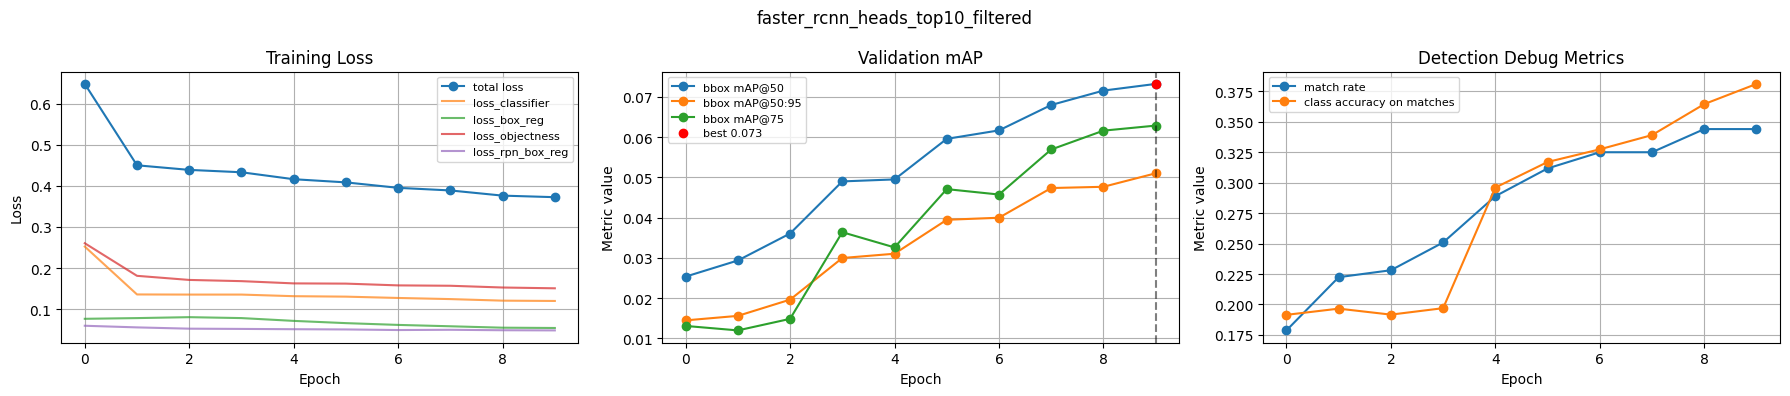

,run_prefix,epoch,eval/bbox_map_50,eval/bbox_map,eval/bbox_map_75,eval/bbox_mar_100,eval/match_rate,eval/class_accuracy_on_matches,eval/pred_instances,eval/images_with_no_matches
9,faster_rcnn_heads_top10_filtered,9,0.073248,0.051028,0.062885,0.214495,0.344106,0.381215,2982.0,102.0


In [19]:
plot_faster_rcnn_run(
    "faster_rcnn_heads_top10_filtered",
    checkpoint_dir=os.path.join(DEFAULT_RUNS_PATH, "checkpoints"),
)


**Observations.** The raw top-10 heads run is expected to be a weak baseline. If the plot shows a low but steadily increasing mAP curve, the detector is learning the task, but the original labels remain too fragmented for strong class-level performance.


In [19]:
!rclone copy ./taco_trash gdrive:taco_trash --progress
!rclone copy checkpoints gdrive:taco_trash/checkpoints --progress

2026/07/12 21:38:10 NOTICE: gdrive: This remote uses rclone's shared Google Drive client_id, which is being retired and will stop working during 2026. Create your own client_id to avoid interruption: https://rclone.org/drive/#making-your-own-client-id
Transferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                 0 / 0, -, Listed 115
Elapsed time:         0.4sTransferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                 0 / 0, -, Listed 120
Elapsed time:         0.9sTransferred:   	    6.754 KiB / 456.579 MiB, 0%, 0 B/s, ETA -
Checks:                 0 / 0, -, Listed 267
Transferred:            0 / 5, 0%
Elapsed time:         1.4s
Transferring:
 * checkpoints/faster_rcn…ed_cosine_20_train.csv:100% / 1.768 KiB, 0 B/s, -
 * checkpoints/faster_rcn…ged_cosine_20_eval.csv:100% / 4.986 KiB, 0 B/s, -
 * checkpoints/faster_rcn…osine_20_last_model.pt:  0% / 228.276 MiB, 0 B/s, -
 * checkpoints/faster_rcn…osine_20_best_model.pt:  0% / 228.277 MiB, 0 B/s, -Transferred

### Train Full Model

The full fine-tuning stage starts from the best heads checkpoint and unfreezes the whole model. Different learning rates are used for the backbone and detection heads to avoid damaging generic visual features while still adapting the detector to trash objects.


In [29]:
model = get_faster_rcnn_model(
    num_classes=num_classes,
    train_mode="all",
    device=device,
    min_size=1024,
    max_size=1536,
)

_ = faster_rcnn_load_checkpoint(
    path=os.path.join(
        DEFAULT_RUNS_PATH,
        "checkpoints",
        "faster_rcnn_heads_top10_filtered_best_model.pt",
    ),
    model=model,
    device=device,
)

optimizer = torch.optim.SGD(
    [
        {"params": model.backbone.parameters(), "lr": 1e-5},
        {"params": model.rpn.parameters(), "lr": 1e-4},
        {"params": model.roi_heads.parameters(), "lr": 1e-4},
    ],
    momentum=0.9,
    weight_decay=5e-4,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
)

scaler = torch.amp.GradScaler("cuda") if device == "cuda" else None

run_prefix = "faster_rcnn_full_top10_filtered"

writer = SummaryWriter(
    log_dir=os.path.join(DEFAULT_RUNS_PATH, "runs", run_prefix)
)

history = faster_rcnn_train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=scaler,
    writer=writer,
    num_epoch=20,
    run_prefix=run_prefix,
    device=device,
    checkpoint_dir=os.path.join(DEFAULT_RUNS_PATH, "checkpoints"),
    eval_every=1,
    scheduler_step_fn=faster_rcnn_step_on_val_bbox_map_50,
    checkpoint_score_fn=faster_rcnn_score_by_eval_bbox_map_50,
    id_to_name=id_to_name,
)

Train model. Epoch 20: 100%|██████████| 20/20 [52:58<00:00, 158.90s/it]


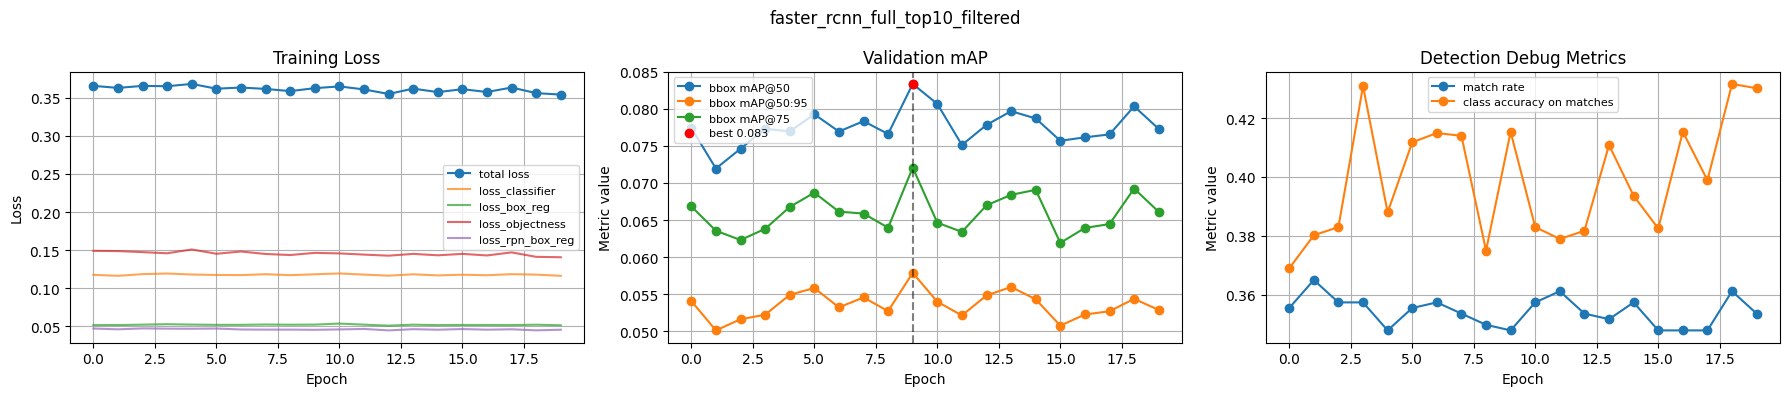

,run_prefix,epoch,eval/bbox_map_50,eval/bbox_map,eval/bbox_map_75,eval/bbox_mar_100,eval/match_rate,eval/class_accuracy_on_matches,eval/pred_instances,eval/images_with_no_matches
9,faster_rcnn_full_top10_filtered,9,0.083345,0.057881,0.072062,0.217945,0.347909,0.415301,3305.0,102.0


In [20]:
plot_faster_rcnn_run(
    "faster_rcnn_full_top10_filtered",
    checkpoint_dir=os.path.join(DEFAULT_RUNS_PATH, "checkpoints"),
)


**Observations.** Full fine-tuning should improve over the heads-only baseline if the backbone needs adaptation. If mAP plateaus quickly or fluctuates around the heads result, the limitation is likely data/label quality rather than insufficient training time.


In [30]:
!rclone copy ./taco_trash gdrive:taco_trash --progress
!rclone copy checkpoints gdrive:taco_trash/checkpoints --progress

2026/07/11 23:04:12 NOTICE: gdrive: This remote uses rclone's shared Google Drive client_id, which is being retired and will stop working during 2026. Create your own client_id to avoid interruption: https://rclone.org/drive/#making-your-own-client-id
Transferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                 0 / 0, -, Listed 115
Elapsed time:         0.5sTransferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                 0 / 0, -, Listed 115
Elapsed time:         0.9sTransferred:   	    9.079 KiB / 1.092 GiB, 0%, 0 B/s, ETA -
Checks:                 0 / 0, -, Listed 211
Transferred:            0 / 8, 0%
Elapsed time:         1.5s
Transferring:
 * checkpoints/faster_rcn…p10_filtered_train.csv:100% / 2.465 KiB, 0 B/s, -
 * checkpoints/faster_rcn…filtered_last_model.pt:  0% / 330.815 MiB, 0 B/s, -
 * checkpoints/faster_rcn…op10_filtered_eval.csv:100% / 6.614 KiB, 0 B/s, -
 * checkpoints/faster_rcn…filtered_best_model.pt:  0% / 330.815 MiB, 0 B/s, -Transferred: 

## Train With Merged Classes

The first top-10 experiment uses raw category names and gives weak results. This section repeats training with a reduced/merged taxonomy inspired by the Mask R-CNN v1 experiments. The goal is to reduce class ambiguity and increase the number of examples per target class.


### Setup Merged Classes Dataset

Several visually similar or overlapping supercategories are merged into broader labels, while catch-all categories are removed. This creates a cleaner detection task with fewer ambiguous labels, which should help class accuracy and stabilize mAP.


In [15]:
PLASTIC_MERGE = {"Plastic bag & wrapper", "Other plastic"}
MERGED_NAME   = "Flexible plastic"

In [16]:
def make_merged_taxonomy_df(df):
    """Merge overlapping plastic labels and remove catch-all annotations.
    
    Args:
        df (pd.DataFrame): Object-level annotation dataframe.
    
    Returns:
        tuple[pd.DataFrame, dict, int, dict]: Filtered annotations and class mappings.
    """
    top_supercats = set(df["supercategory"].value_counts().head(10).index)

    # Replace merged classes with a single name before deciding what to keep
    df_new = df.copy()
    df_new["label_merged"] = df_new["supercategory"].replace(
        {c: MERGED_NAME for c in PLASTIC_MERGE}
    )

    # Keep only explicit classes — drop everything that would fall into "Other"
    keep = top_supercats - PLASTIC_MERGE | {MERGED_NAME}
    df_new = df_new[df_new["label_merged"].isin(keep)].copy()

    label_values = sorted(df_new["label_merged"].unique())
    label_map    = {name: i + 1 for i, name in enumerate(label_values)}
    num_classes  = len(label_map) + 1
    id_to_name   = {v: k for k, v in label_map.items()}

    print(f"Classes ({len(label_map)}): {label_values}")
    print(f"Annotations: {len(df_new)} (was {len(df)})")
    return df_new, label_map, num_classes, id_to_name

In [20]:
df_fast_final, label_map_fast_final, num_classes_fast_final, id_to_name_fast_final = make_merged_taxonomy_df(df)

train_loader_fast_final, val_loader_fast_final = get_faster_rcnn_loaders(
    df=df_fast_final,
    label_map=label_map_fast_final,
    label_col="label_merged",
    train_transform=None,
    train_batch_size=2,
    val_batch_size=4,
    num_workers=4,
    use_sampler=False,
)

print(label_map_fast_final)
print(num_classes_fast_final)

Classes (9): ['Bottle', 'Bottle cap', 'Can', 'Carton', 'Cigarette', 'Cup', 'Flexible plastic', 'Straw', 'Unlabeled litter']
Annotations: 3912 (was 4784)
{'Bottle': 1, 'Bottle cap': 2, 'Can': 3, 'Carton': 4, 'Cigarette': 5, 'Cup': 6, 'Flexible plastic': 7, 'Straw': 8, 'Unlabeled litter': 9}
10


### Train Heads

In the heads stage, the backbone is frozen and only the RPN and ROI heads are trained. This checks whether the pretrained visual features are sufficient for the TACO detection task and provides a cheap baseline before full fine-tuning.


In [17]:
# https://drive.google.com/file/d/1f7Q-N3FFYgrnX0F2mA3SrEJ23J30OGtZ/view?usp=sharing
!gdown 1f7Q-N3FFYgrnX0F2mA3SrEJ23J30OGtZ -O checkpoints/faster_rcnn_heads_merged_cosine_20_best_model.pt

Downloading...
From (original): https://drive.google.com/uc?id=1f7Q-N3FFYgrnX0F2mA3SrEJ23J30OGtZ
From (redirected): https://drive.google.com/uc?id=1f7Q-N3FFYgrnX0F2mA3SrEJ23J30OGtZ&confirm=t&uuid=92752a12-4d29-4297-84fa-56e3ce87f412
To: /home/ubuntu/checkpoints/faster_rcnn_heads_merged_cosine_20_best_model.pt
100%|███████████████████████████████████████| 239M/239M [00:02<00:00, 98.3MB/s]


In [24]:
model_fast = get_faster_rcnn_model(
    num_classes=num_classes_fast_final,
    train_mode="heads",
    device=device,
    min_size=1024,
    max_size=1536,
)

_ = faster_rcnn_load_checkpoint(
    path=os.path.join(
        "checkpoints",
        "faster_rcnn_heads_merged_cosine_20_best_model.pt",
    ),
    model=model_fast,
    device=device,
)

optimizer_fast = torch.optim.SGD(
    [p for p in model_fast.parameters() if p.requires_grad],
    lr=1e-3,
    momentum=0.9,
    weight_decay=5e-4,
)

scheduler_fast = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_fast,
    T_max=20,
    eta_min=1e-6,
)

scaler_fast = torch.amp.GradScaler("cuda") if device == "cuda" else None

run_prefix_fast = "faster_rcnn_heads_merged_cosine_20"

writer_fast = SummaryWriter(
    log_dir=os.path.join(DEFAULT_RUNS_PATH, "runs", run_prefix_fast)
)

history_fast = faster_rcnn_train_model(
    model=model_fast,
    train_loader=train_loader_fast_final,
    val_loader=val_loader_fast_final,
    optimizer=optimizer_fast,
    scheduler=scheduler_fast,
    scaler=scaler_fast,
    writer=writer_fast,
    num_epoch=20,
    run_prefix=run_prefix_fast,
    device=device,
    checkpoint_dir=os.path.join(DEFAULT_RUNS_PATH, "checkpoints"),
    eval_every=1,
    scheduler_step_fn=faster_rcnn_step_scheduler_default,
    checkpoint_score_fn=faster_rcnn_score_by_eval_bbox_map_50,
    id_to_name=id_to_name_fast_final,
    start_epoch=13
)

Train model. Epoch 20: 100%|██████████| 7/7 [20:16<00:00, 173.79s/it]


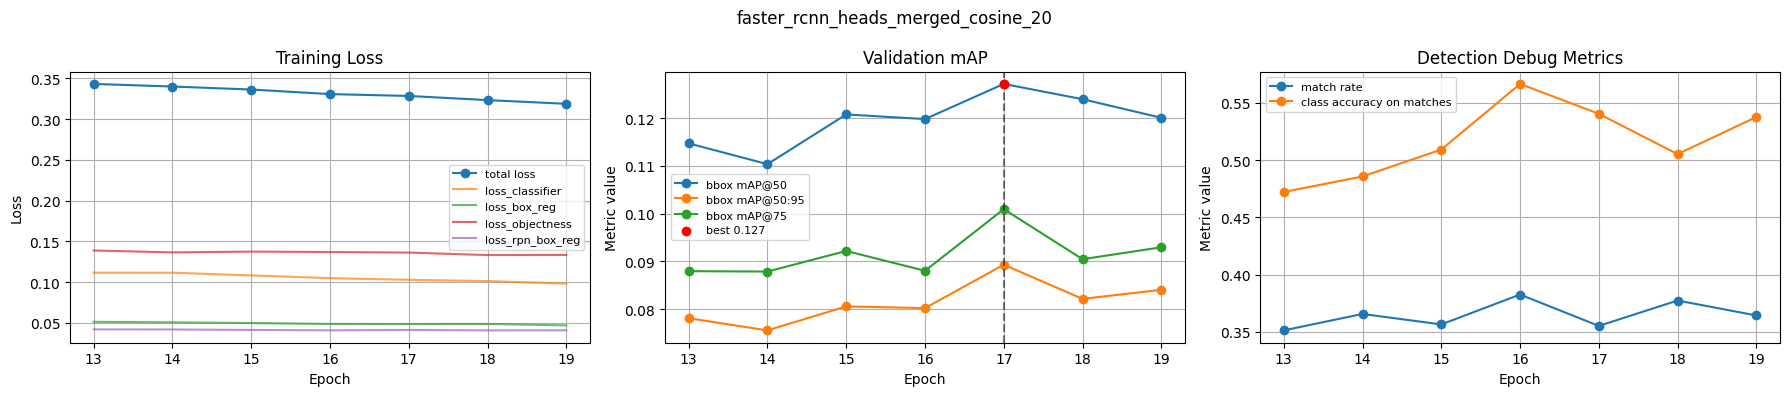

,run_prefix,epoch,eval/bbox_map_50,eval/bbox_map,eval/bbox_map_75,eval/bbox_mar_100,eval/match_rate,eval/class_accuracy_on_matches,eval/pred_instances,eval/images_with_no_matches
4,faster_rcnn_heads_merged_cosine_20,17,0.127175,0.089305,0.100936,0.216457,0.355091,0.540441,3606.0,118.0


In [22]:
plot_faster_rcnn_run(
    "faster_rcnn_heads_merged_cosine_20",
    checkpoint_dir=os.path.join(DEFAULT_RUNS_PATH, "checkpoints"),
)


**Observations.** The merged-label heads run should be compared directly with the raw top-10 heads run. A higher mAP and higher class accuracy on matches indicate that reducing label ambiguity helps Faster R-CNN learn cleaner decision boundaries.


In [25]:
!rclone copy ./taco_trash gdrive:taco_trash --progress
!rclone copy checkpoints gdrive:taco_trash/checkpoints --progress

2026/07/13 10:30:12 NOTICE: Config file "/home/ubuntu/.config/rclone/rclone.conf" not found - using defaults
2026/07/13 10:30:12 CRITICAL: Failed to create file system for "gdrive:taco_trash": didn't find section in config file ("gdrive")
2026/07/13 10:30:12 NOTICE: Config file "/home/ubuntu/.config/rclone/rclone.conf" not found - using defaults
2026/07/13 10:30:12 CRITICAL: Failed to create file system for "gdrive:taco_trash/checkpoints": didn't find section in config file ("gdrive")


### Train Full Model

The full fine-tuning stage starts from the best heads checkpoint and unfreezes the whole model. Different learning rates are used for the backbone and detection heads to avoid damaging generic visual features while still adapting the detector to trash objects.


In [26]:
model_fast_full = get_faster_rcnn_model(
    num_classes=num_classes_fast_final,
    train_mode="all",
    device=device,
    min_size=1024,
    max_size=1536,
)

_ = faster_rcnn_load_checkpoint(
    path=os.path.join(
        DEFAULT_RUNS_PATH,
        "checkpoints",
        "faster_rcnn_heads_merged_cosine_20_best_model.pt",
    ),
    model=model_fast_full,
    device=device,
)

optimizer_fast_full = torch.optim.SGD(
    [
        {"params": model_fast_full.backbone.parameters(), "lr": 1e-4},
        {"params": model_fast_full.rpn.parameters(), "lr": 1e-3},
        {"params": model_fast_full.roi_heads.parameters(), "lr": 1e-3},
    ],
    momentum=0.9,
    weight_decay=5e-4,
)

scheduler_fast_full = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_fast_full,
    T_max=30,
    eta_min=1e-6,
)

scaler_fast_full = torch.amp.GradScaler("cuda") if device == "cuda" else None

run_prefix_fast_full = "faster_rcnn_full_merged_cosine_30"

writer_fast_full = SummaryWriter(
    log_dir=os.path.join(DEFAULT_RUNS_PATH, "runs", run_prefix_fast_full)
)

history_fast_full = faster_rcnn_train_model(
    model=model_fast_full,
    train_loader=train_loader_fast_final,
    val_loader=val_loader_fast_final,
    optimizer=optimizer_fast_full,
    scheduler=scheduler_fast_full,
    scaler=scaler_fast_full,
    writer=writer_fast_full,
    num_epoch=30,
    run_prefix=run_prefix_fast_full,
    device=device,
    checkpoint_dir=os.path.join(DEFAULT_RUNS_PATH, "checkpoints"),
    eval_every=1,
    scheduler_step_fn=faster_rcnn_step_scheduler_default,
    checkpoint_score_fn=faster_rcnn_score_by_eval_bbox_map_50,
    id_to_name=id_to_name_fast_final,
)

Train model. Epoch 30: 100%|██████████| 30/30 [1:40:23<00:00, 200.77s/it]


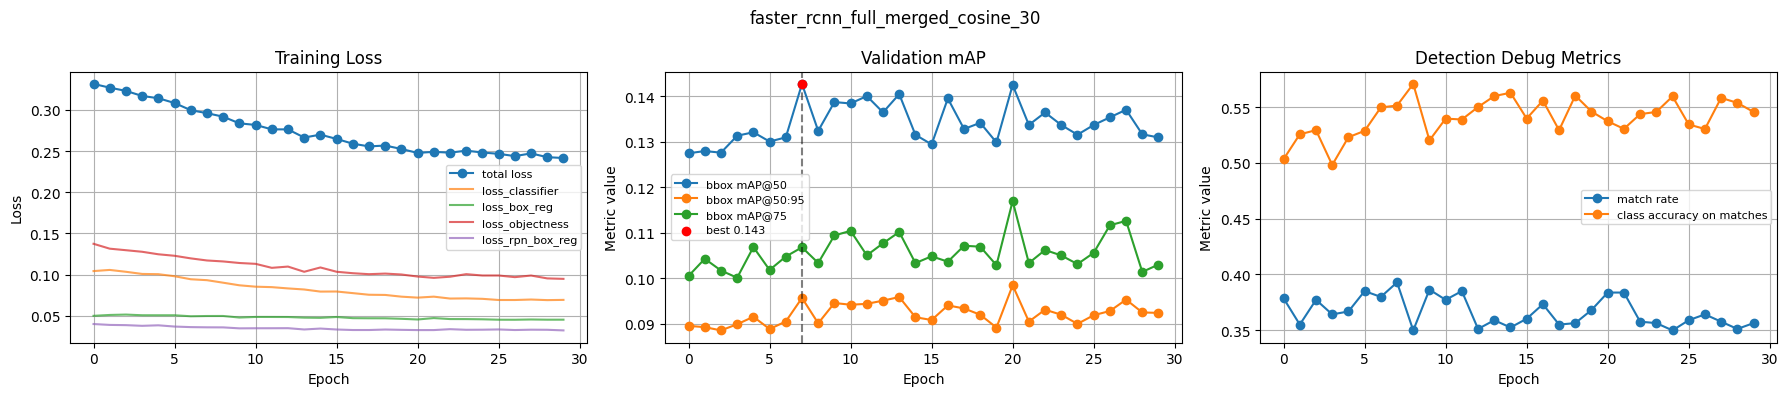

,run_prefix,epoch,eval/bbox_map_50,eval/bbox_map,eval/bbox_map_75,eval/bbox_mar_100,eval/match_rate,eval/class_accuracy_on_matches,eval/pred_instances,eval/images_with_no_matches
7,faster_rcnn_full_merged_cosine_30,7,0.142734,0.095711,0.10683,0.225504,0.39295,0.551495,3841.0,111.0


In [21]:
plot_faster_rcnn_run(
    "faster_rcnn_full_merged_cosine_30",
    checkpoint_dir=os.path.join(DEFAULT_RUNS_PATH, "checkpoints"),
)


**Observations.** This is the strongest Faster R-CNN configuration in the notebook. The key question is whether full fine-tuning gives a meaningful jump over merged heads training. If the best epoch appears early and later epochs fluctuate, the model has saturated and further training is unlikely to help.


In [28]:
!rclone copy ./taco_trash gdrive:taco_trash --progress
!rclone copy checkpoints gdrive:taco_trash/checkpoints --progress

2026/07/13 13:23:38 NOTICE: gdrive: This remote uses rclone's shared Google Drive client_id, which is being retired and will stop working during 2026. Create your own client_id to avoid interruption: https://rclone.org/drive/#making-your-own-client-id
Transferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                 0 / 0, -, Listed 115
Elapsed time:         0.4sTransferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                 0 / 0, -, Listed 125
Elapsed time:         0.9sTransferred:   	   13.760 KiB / 1.092 GiB, 0%, 0 B/s, ETA -
Checks:                 4 / 4, 100%, Listed 280
Transferred:            0 / 11, 0%
Elapsed time:         1.4s
Transferring:
 * checkpoints/faster_rcn…osine_30_best_model.pt:  0% / 330.777 MiB, 0 B/s, -
 * checkpoints/faster_rcn…ged_cosine_30_eval.csv:100% / 10.096 KiB, 0 B/s, -
 * checkpoints/faster_rcn…osine_30_last_model.pt:  0% / 330.777 MiB, 0 B/s, -
 * checkpoints/faster_rcn…ed_cosine_30_train.csv:100% / 3.664 KiB, 0 B/s, -Transfer

## Common Conclusion

Faster R-CNN was evaluated as a detection-only alternative to Mask R-CNN. The raw top-10 category setup was useful as a baseline, but its metrics remained low because the original labels are fragmented and visually ambiguous. Applying the same data-treatment idea used in the Mask R-CNN v1 experiments — merged classes, original bounding boxes, staged heads/full training, and cosine scheduling — improved the results.

The best Faster R-CNN configuration was the merged-taxonomy full fine-tuning run. It improved over the raw top-10 setup, but the improvement was limited: the model saturated around a low bbox mAP@50 compared with the final YOLO11l top-5 detector. The debug metrics show that class accuracy on matched boxes improved after merging labels, but the match rate stayed relatively low, meaning many ground-truth objects were still not localized well enough.

Therefore, Faster R-CNN is useful in this project as a comparison baseline and as evidence that cleaner taxonomy helps detection. However, it is not selected as the final inference model because it does not reach the required detection quality. The final application should continue using the YOLO11l top-5 model, while Faster R-CNN can be reported as a weaker two-stage detector baseline.
